In [ ]:
import numpy as np
from google.colab.patches import cv2_imshow
import cv2
import sklearn
img = cv2.imread('chetah.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pxl = img.reshape((-1, 3)).astype(np.float64)
print(pxl.shape)

(375000, 3)


In [ ]:
sample_size = min(10000, pxl.shape[0])
rng = np.random.default_rng(0)
sample_idx = rng.choice(pxl.shape[0], size=sample_size, replace=False)
pixel_sample = pxl[sample_idx]
kmeans = sklearn.cluster.MiniBatchKMeans(n_clusters=256, random_state=0, batch_size=4096, n_init=3)
kmeans.fit(pixel_sample)
labels = kmeans.predict(pxl).astype(np.uint8)
centers = np.round(kmeans.cluster_centers_).astype(np.uint8)

#- IGNORE
#- IGNORE
#- IGNORE
#- IGNORE

Original Image:


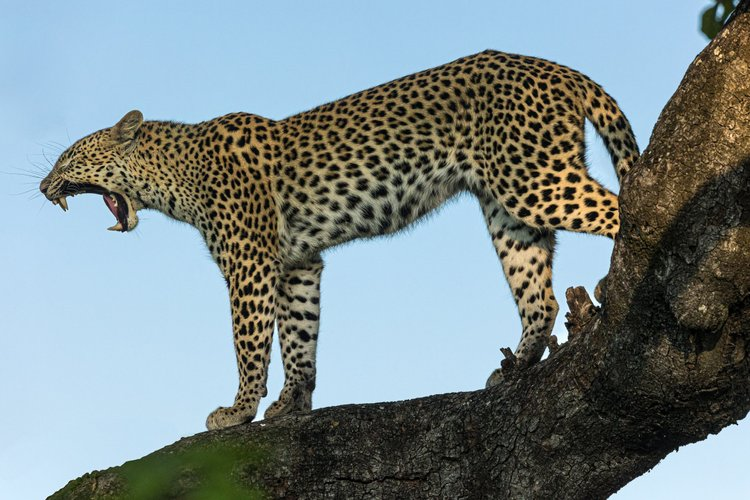

In [ ]:
print("Original Image:")
cv2_imshow(cv2.cvtColor(img,cv2.COLOR_RGB2BGR))

Max and Min values of the labels for verification
[101 101 101 ... 206 206 206] 0 255 (375000,)
Reconstructed indices Gray Level img


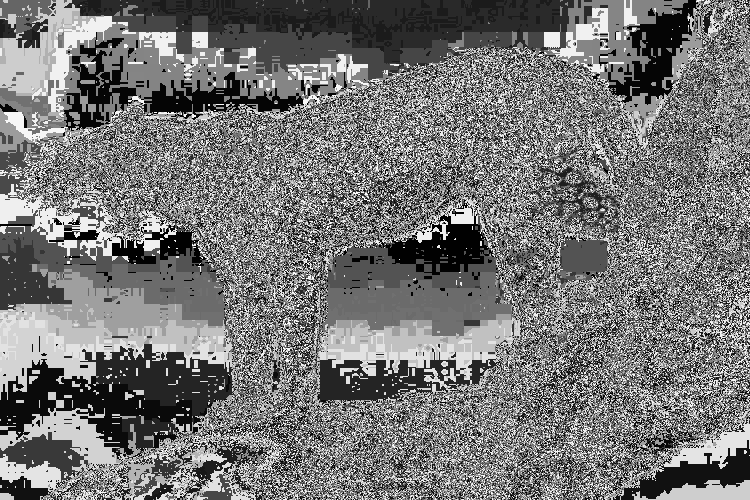

In [ ]:
print("Max and Min values of the labels for verification")
print(labels,min(labels),max(labels),labels.shape)
print("Reconstructed indices Gray Level img")
cv2_imshow(labels.reshape((img.shape[0],img.shape[1])))

Reconstructed img


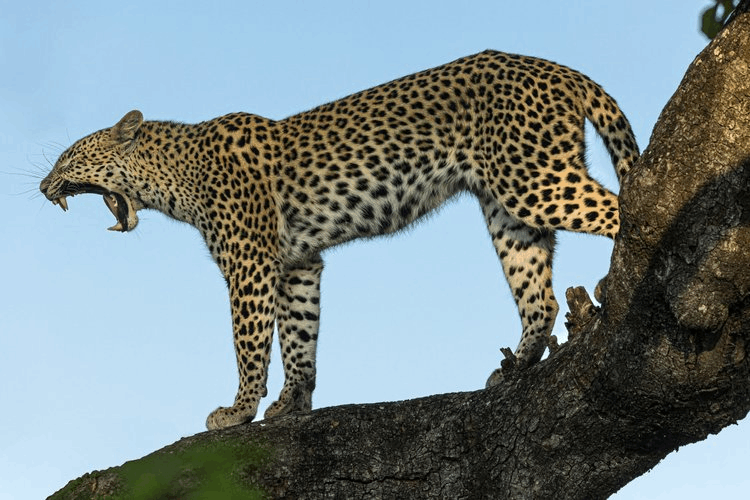

In [ ]:
print("Reconstructed img")
cv2_imshow(cv2.cvtColor(centers[labels].reshape(img.shape).astype(np.uint8),cv2.COLOR_RGB2BGR))

# Compression Ratio Calculation
1. Original Size (in bits) = 500 x 750 x 3 x 8 = 90,00,000
*  in byte's : ~1.12MB
2. Indices Bit are 8 bit so
* Size(bits) = 30,00,000, colour map Bits = 256 x 3 x 8 = 6,144
* compressed net bits = 30,06,144, hence bytes = 375KB
3. Compression Ratio = 11,25,000/375,768 = 2.99